In [ ]:
# Import libraries

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# Gradient Boosting Models
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

In [ ]:
# Load data
df = pd.read_csv("YOUR FILE")

# Preview data
df.head()

,Platform,Profile,Link,Text,Date,Type,Engagement,Engagement Rate,Followers,Likes,Comments,Shares,Reach,Impressions,Video Views,Brand Content Pillars,Industry Content Pillars,Country,Unnamed: 18
0,instagram,Kompas.com,https://www.instagram.com/reel/DZepebgS-a2/,Mahasiswa meminta aparat agar tidak represif s...,2026-06-12 03:34 PM,reel,541552,18.350989,2951078,531858,9694,0,3761405,6037568,0,NaN,Human & Civil Rights;Tech News & Innovation Sp...,NaN,NaN
1,instagram,Kompas.com,https://www.instagram.com/reel/DZfCpkMSpNR/,Perwakilan ibu-ibu memprotes pemblokadean laju...,2026-06-12 07:00 PM,reel,363520,12.318210,2951078,349586,13934,0,2710041,4349986,0,NaN,Tech News & Innovation Spotlights;Conflict & P...,NaN,NaN
2,instagram,kumparan,https://www.instagram.com/reel/DZFNqItCY5c/,Mantan Mendikbudristek Nadiem Makarim menjalan...,2026-06-02 06:18 PM,reel,350668,12.961593,2705439,342236,8432,0,2426833,3895398,0,NaN,Climate & Environmental Advocacy;Breaking News...,NaN,NaN
3,instagram,Kompas.com,https://www.instagram.com/reel/DZ7sF2qyMOu/,Ketua BEM Fakultas Hukum Universitas Bung Karn...,2026-06-23 10:02 PM,reel,337098,11.422877,2951078,316485,20613,0,2738406,4395515,0,NaN,Business Insights & Market Analysis,NaN,NaN
4,instagram,tempo.co by Tempo Media Group,https://www.instagram.com/reel/DZfBAR0DmOP/,Ketua Badan Eksekutif Mahasiswa Universitas In...,2026-06-12 06:45 PM,reel,304581,15.369458,1981729,300935,3646,0,2938450,4716613,0,NaN,Breaking News & Headlines;Conflict & Peace Ini...,NaN,NaN


In [ ]:
# Data information
print("Data Shape")
print(df.shape)

print("\nData Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

Data Shape
(3756, 19)

Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3756 entries, 0 to 3755
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Platform                  3756 non-null   object 
 1   Profile                   3756 non-null   object 
 2   Link                      3756 non-null   object 
 3   Text                      3748 non-null   object 
 4   Date                      3756 non-null   object 
 5   Type                      3756 non-null   object 
 6   Engagement                3756 non-null   int64  
 7   Engagement Rate           3756 non-null   float64
 8   Followers                 3756 non-null   int64  
 9   Likes                     3756 non-null   int64  
 10  Comments                  3756 non-null   int64  
 11  Shares                    3756 non-null   int64  
 12  Reach                     3756 non-null   int64  
 13  Impressions               3756

In [ ]:
# Data cleaning

# Remove duplicate rows
df = df.drop_duplicates()

# Remove missing values only in the 'Text' column
df = df.dropna(subset=['Text'])


# Drop unnecessary columns
df = df.drop(columns=[
    "Shares",
    "Video Views",
    "Brand Content Pillars",
    "Industry Content Pillars",
    "Country",
    "Unnamed: 18"
])

df.head()

,Platform,Profile,Link,Text,Date,Type,Engagement,Engagement Rate,Followers,Likes,Comments,Reach,Impressions
0,instagram,Kompas.com,https://www.instagram.com/reel/DZepebgS-a2/,Mahasiswa meminta aparat agar tidak represif s...,2026-06-12 03:34 PM,reel,541552,18.350989,2951078,531858,9694,3761405,6037568
1,instagram,Kompas.com,https://www.instagram.com/reel/DZfCpkMSpNR/,Perwakilan ibu-ibu memprotes pemblokadean laju...,2026-06-12 07:00 PM,reel,363520,12.318210,2951078,349586,13934,2710041,4349986
2,instagram,kumparan,https://www.instagram.com/reel/DZFNqItCY5c/,Mantan Mendikbudristek Nadiem Makarim menjalan...,2026-06-02 06:18 PM,reel,350668,12.961593,2705439,342236,8432,2426833,3895398
3,instagram,Kompas.com,https://www.instagram.com/reel/DZ7sF2qyMOu/,Ketua BEM Fakultas Hukum Universitas Bung Karn...,2026-06-23 10:02 PM,reel,337098,11.422877,2951078,316485,20613,2738406,4395515
4,instagram,tempo.co by Tempo Media Group,https://www.instagram.com/reel/DZfBAR0DmOP/,Ketua Badan Eksekutif Mahasiswa Universitas In...,2026-06-12 06:45 PM,reel,304581,15.369458,1981729,300935,3646,2938450,4716613


In [ ]:
# Standardize post types
df['Type'] = df['Type'].replace({
    'reel': 'Reel',
    'carousel_album': 'Carousel',
    'image': 'Image'
})
df['Type'].value_counts()

,count
Type,
Reel,2342
Carousel,725
Image,681


In [ ]:
# Standardize profile name
df['Profile'] = df['Profile'].replace({
    'Kompas.com': 'Kompas',
    'detikcom': 'Detik',
    'tempo.co by Tempo Media Group': 'Tempo',
    'kumparan': 'Kumparan',
    'Tribunnews.com': 'Tribunnews'
})
df['Profile'].value_counts()

,count
Profile,
Kumparan,1116
Tribunnews,774
Detik,686
Kompas,663
Tempo,509


In [ ]:
# Check dataset shape after cleaning
df.shape

(3748, 13)

# EDA

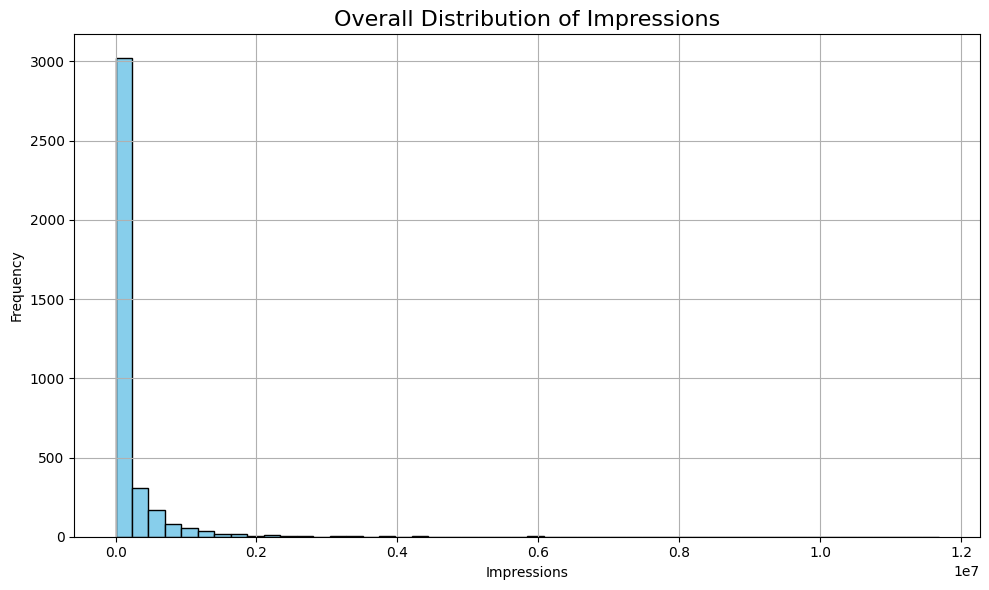

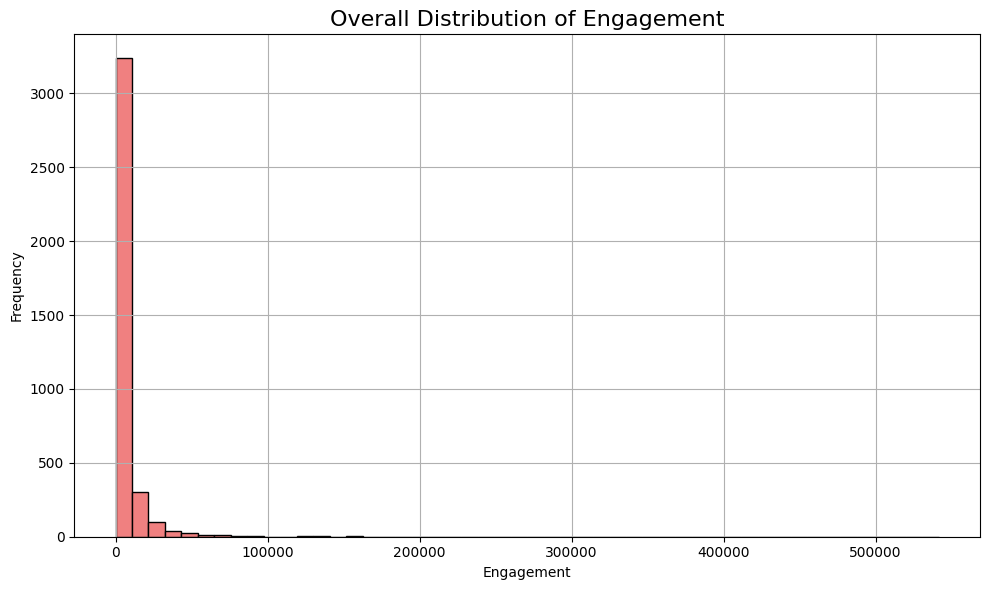

In [ ]:
# Plot overall Impressions distribution
plt.figure(figsize=(10, 6))
plt.title('Overall Distribution of Impressions', fontsize=16)
df['Impressions'].hist(bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Impressions')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot overall Engagement distribution
plt.figure(figsize=(10, 6))
plt.title('Overall Distribution of Engagement', fontsize=16)
df['Engagement'].hist(bins=50, color='lightcoral', edgecolor='black')
plt.xlabel('Engagement')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

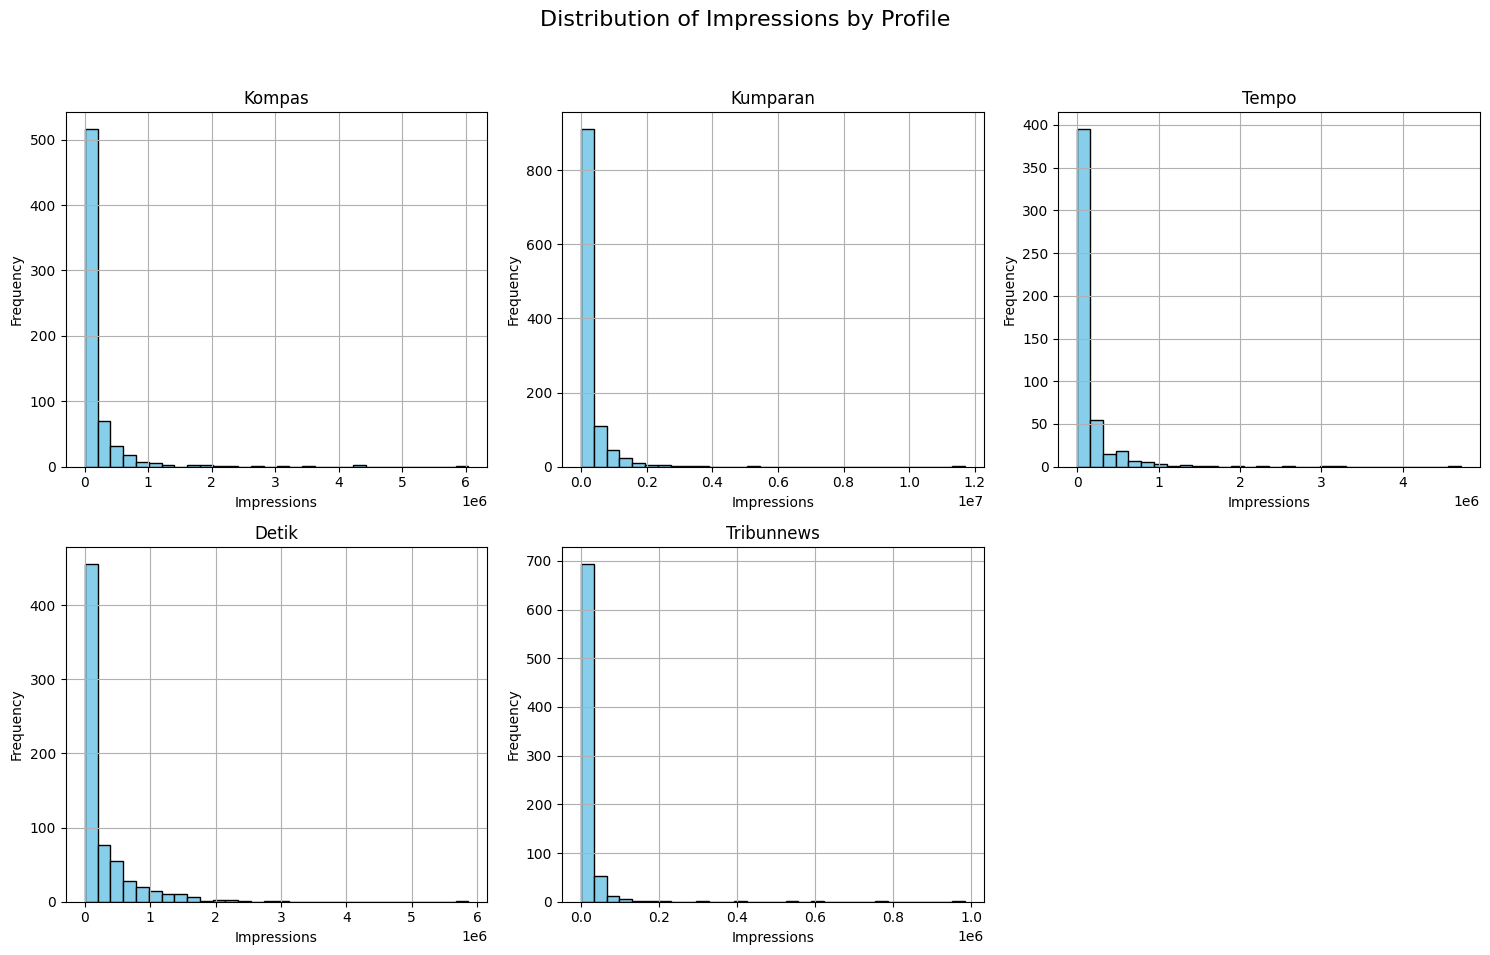

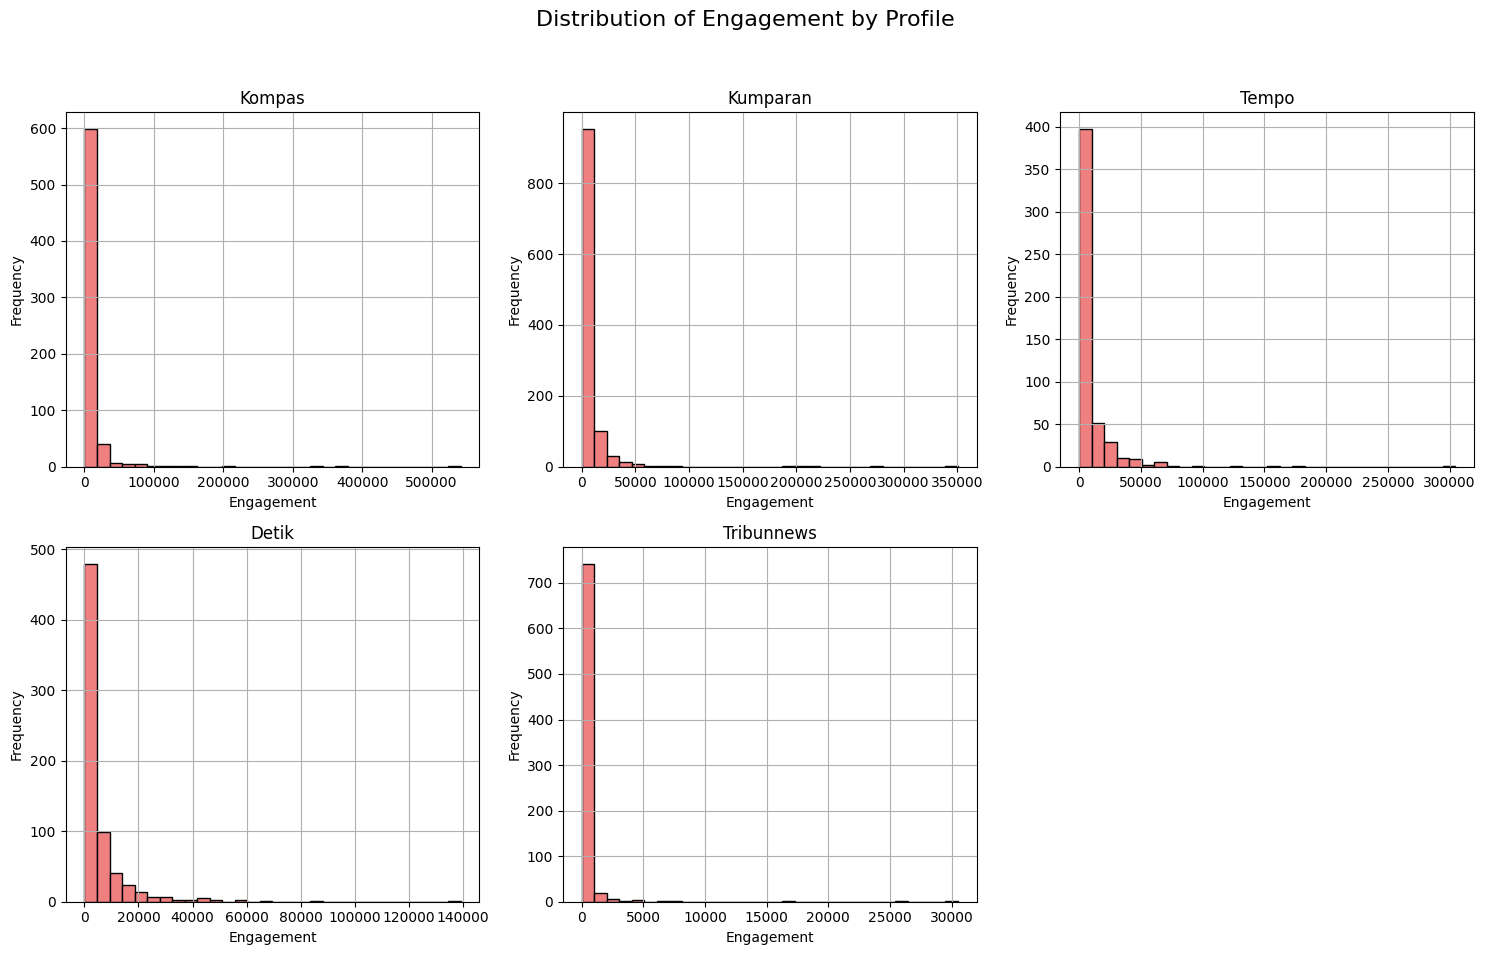

In [ ]:
# Get all unique Instagram profiles
profiles = df["Profile"].unique()

# Plot Impressions distribution for each profile
plt.figure(figsize=(15, 10))
plt.suptitle("Distribution of Impressions by Profile", fontsize=16)

for i, profile in enumerate(profiles):
    plt.subplot(2, 3, i + 1)

    df[df["Profile"] == profile]["Impressions"].hist(
        bins=30,
        color="skyblue",
        edgecolor="black"
    )

    plt.title(profile)
    plt.xlabel("Impressions")
    plt.ylabel("Frequency")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# Plot Engagement distribution for each profile
plt.figure(figsize=(15, 10))
plt.suptitle("Distribution of Engagement by Profile", fontsize=16)

for i, profile in enumerate(profiles):
    plt.subplot(2, 3, i + 1)

    df[df["Profile"] == profile]["Engagement"].hist(
        bins=30,
        color="lightcoral",
        edgecolor="black"
    )

    plt.title(profile)
    plt.xlabel("Engagement")
    plt.ylabel("Frequency")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/tmp/ipykernel_1972/2055551618.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


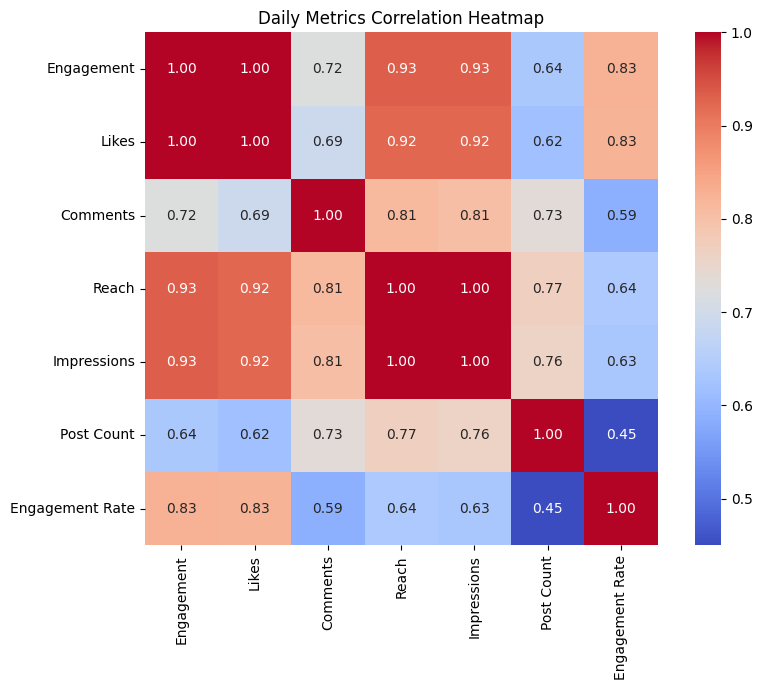

In [ ]:
# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Aggregate metrics by day
daily_metrics = (
    df.groupby(df["Date"].dt.normalize())
      .agg({
          "Engagement": "sum",
          "Likes": "sum",
          "Comments": "sum",
          "Reach": "sum",
          "Impressions": "sum",
          "Profile": "count"
      })
      .rename(columns={"Profile": "Post Count"})
)

# Calculate daily engagement rate
daily_metrics["Engagement Rate"] = (
    daily_metrics["Engagement"] / daily_metrics["Reach"]
)

# Calculate correlation matrix
corr_matrix = daily_metrics.corr()

# Plot correlation heatmap
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Daily Metrics Correlation Heatmap")
plt.tight_layout()
plt.show()

Profile
Kumparan      8008249
Kompas        6535803
Tempo         4776729
Detik         3527609
Tribunnews     230326
Name: Engagement, dtype: int64


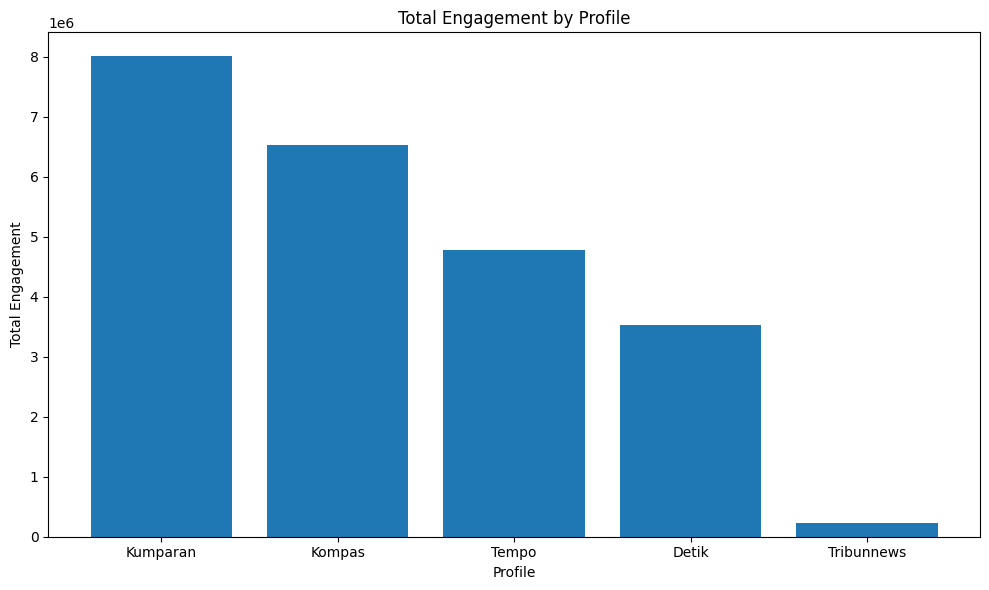

In [ ]:
# Calculate total engagement by profile
total_engagement_per_profile = (
    df.groupby("Profile")["Engagement"]
      .sum()
      .sort_values(ascending=False)
)

# Display total engagement values
print(total_engagement_per_profile)

# Create bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    total_engagement_per_profile.index,
    total_engagement_per_profile.values
)

plt.title("Total Engagement by Profile")
plt.xlabel("Profile")
plt.ylabel("Total Engagement")

plt.tight_layout()
plt.show()

Profile
Kumparan      186583268
Detik         112852104
Kompas         88650266
Tempo          59085383
Tribunnews      8294296
Name: Reach, dtype: int64


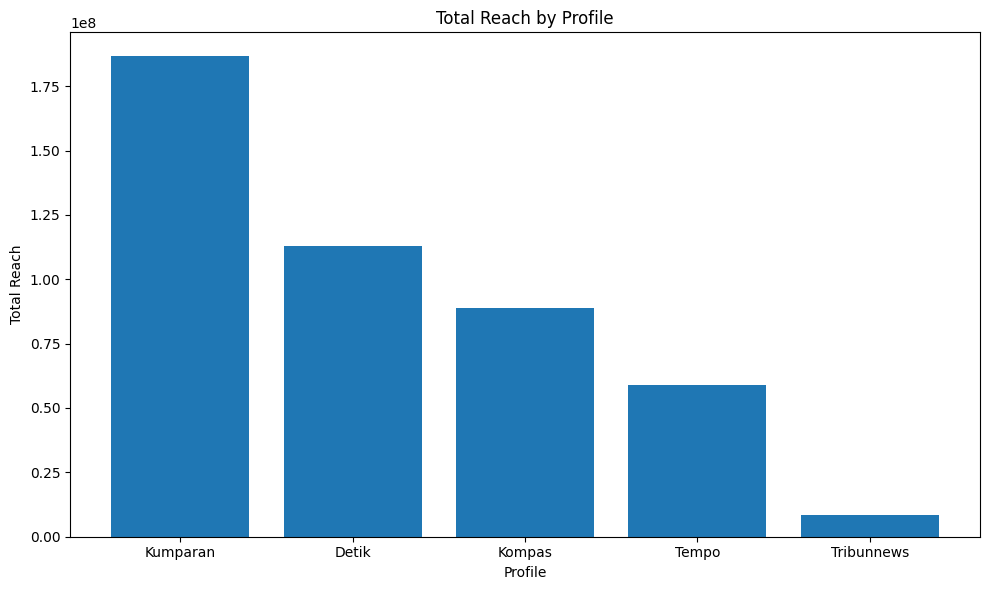

In [ ]:
# Calculate total reach by profile
total_reach_per_profile = (
    df.groupby("Profile")["Reach"]
      .sum()
      .sort_values(ascending=False)
)

# Display total reach values
print(total_reach_per_profile)

# Create bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    total_reach_per_profile.index,
    total_reach_per_profile.values
)

plt.title("Total Reach by Profile")
plt.xlabel("Profile")
plt.ylabel("Total Reach")

plt.tight_layout()
plt.show()


ENGAGEMENT CATEGORY DISTRIBUTION
engagement_category
Low Performance     2811
High Performance     937
Name: count, dtype: int64


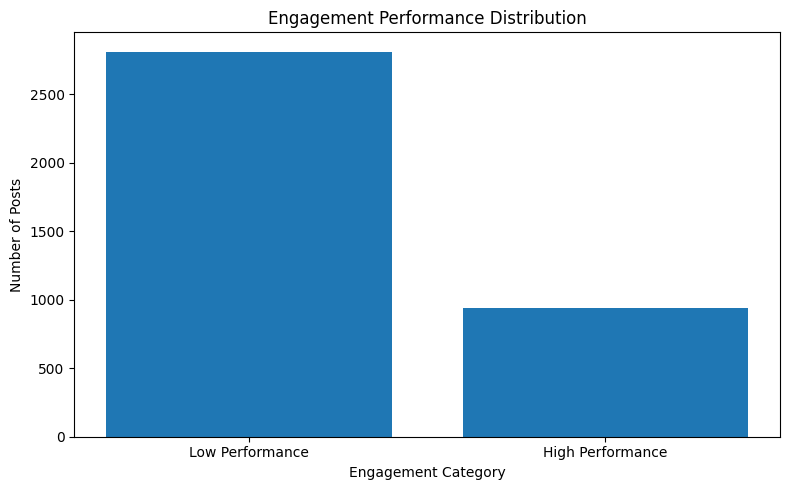

In [ ]:
# Create engagement performance categories
threshold = df["Engagement"].quantile(0.75)

df["engagement_category"] = np.where(
    df["Engagement"] >= threshold,
    "High Performance",
    "Low Performance"
)

# Calculate category distribution
engagement_distribution = (
    df["engagement_category"]
      .value_counts()
)

# Display category distribution
print("\nENGAGEMENT CATEGORY DISTRIBUTION")
print(engagement_distribution)

# Plot engagement category distribution
plt.figure(figsize=(8, 5))

plt.bar(
    engagement_distribution.index,
    engagement_distribution.values
)

plt.title("Engagement Performance Distribution")
plt.xlabel("Engagement Category")
plt.ylabel("Number of Posts")

plt.tight_layout()
plt.show()

Post Count per Profile:
Profile
Kumparan      1116
Tribunnews     774
Detik          686
Kompas         663
Tempo          509
dtype: int64


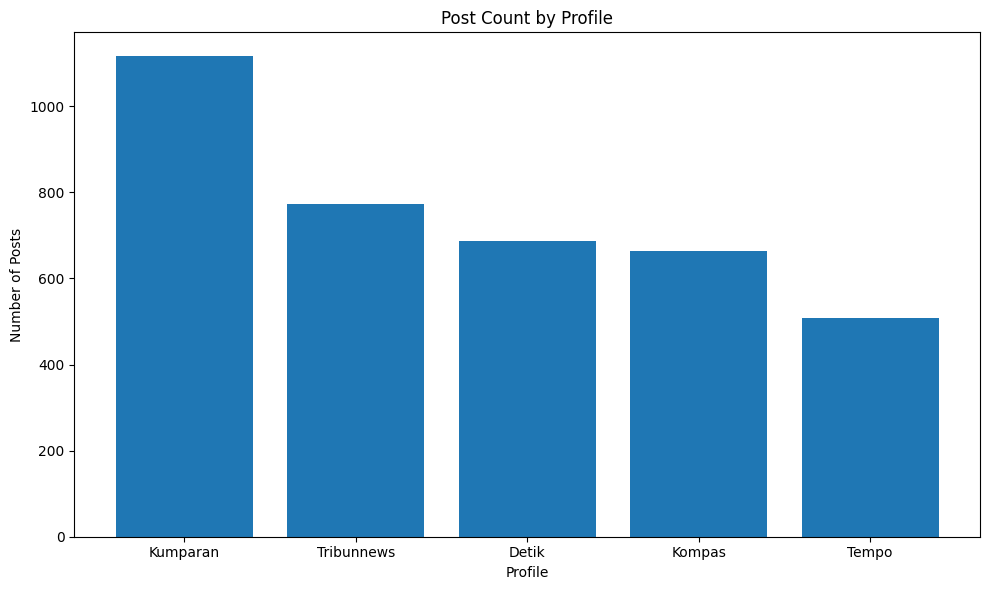

In [ ]:
# Calculate post count by profile
post_count_per_profile = (
    df.groupby("Profile")
      .size()
      .sort_values(ascending=False)
)

# Display post count values
print("Post Count per Profile:")
print(post_count_per_profile)

# Create bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    post_count_per_profile.index,
    post_count_per_profile.values
)

plt.title("Post Count by Profile")
plt.xlabel("Profile")
plt.ylabel("Number of Posts")

plt.tight_layout()
plt.show()

Median Engagement per Post Type:
Type
Reel        1799.5
Image       1603.0
Carousel     812.0
Name: Engagement, dtype: float64


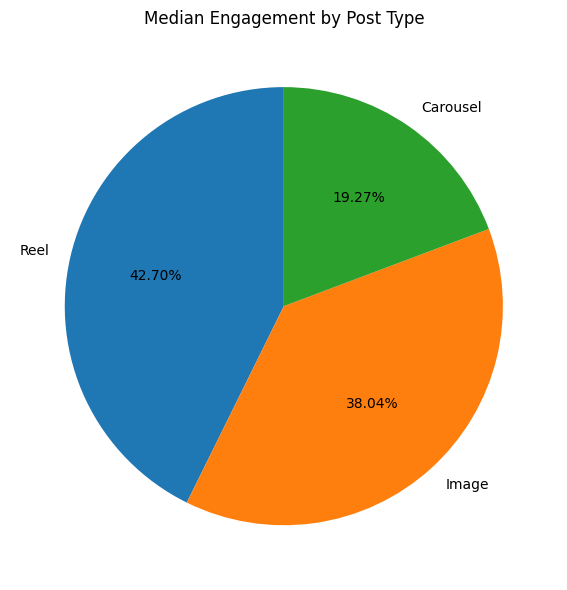

In [ ]:
# Calculate median engagement per post type
median_engagement_per_type = df.groupby('Type')['Engagement'].median().sort_values(ascending=False)

# Display median engagement values
print("Median Engagement per Post Type:")
print(median_engagement_per_type)

# Create pie chart for median engagement per type
plt.figure(figsize=(10, 6))
median_engagement_per_type.plot(kind='pie', autopct='%1.2f%%', startangle=90)
plt.title('Median Engagement by Post Type')
plt.ylabel('') # Hide the default 'Type' label for pie chart
plt.tight_layout()
plt.show()

Median Reach per Post Type:
Type
Reel        58605.0
Image       16080.0
Carousel     8271.0
Name: Reach, dtype: float64


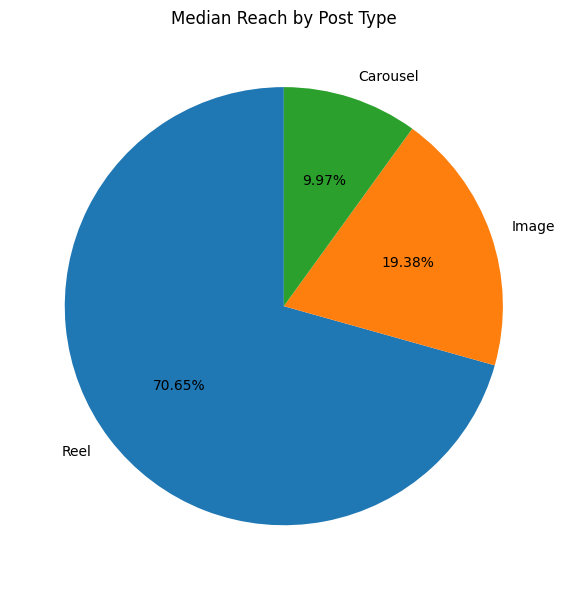

In [ ]:
# Calculate median reach per post type
median_reach_per_type = df.groupby('Type')['Reach'].median().sort_values(ascending=False)

# Display median reach values
print("Median Reach per Post Type:")
print(median_reach_per_type)

# Create pie chart for median reach per type
plt.figure(figsize=(10, 6))
median_reach_per_type.plot(kind='pie', autopct='%1.2f%%', startangle=90)

plt.title('Median Reach by Post Type')
plt.ylabel('')  # Hide the default 'Type' label for pie chart

plt.tight_layout()
plt.show()

Median Engagement by Day of Week
Day of Week
Monday       1469.0
Tuesday      1340.0
Wednesday    1570.0
Thursday     1852.0
Friday       1498.0
Saturday     1141.5
Sunday       1442.0
Name: Engagement, dtype: float64


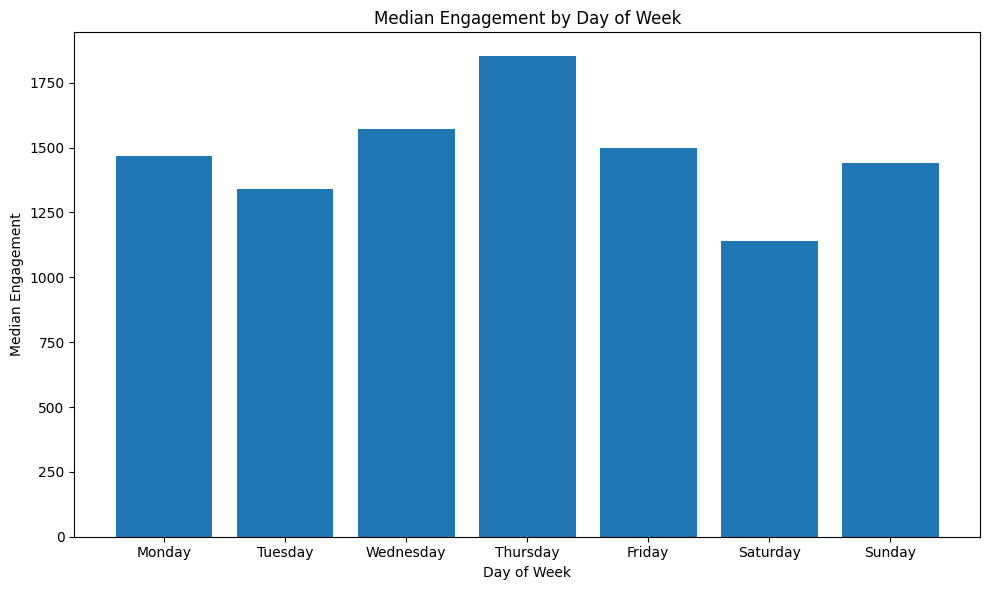

In [ ]:
# Extract day name from posting date
df["Day of Week"] = df["Date"].dt.day_name()

# Define day order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Calculate median engagement by day of week
median_engagement_per_day = (
    df.groupby("Day of Week")["Engagement"]
      .median()
      .reindex(day_order)
)

# Display median engagement values
print("Median Engagement by Day of Week")
print(median_engagement_per_day)

# Create bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    median_engagement_per_day.index,
    median_engagement_per_day.values
)

plt.title("Median Engagement by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Median Engagement")

plt.tight_layout()
plt.show()

Median Reach by Day of Week
Day of Week
Monday       30077.0
Tuesday      33370.0
Wednesday    32995.0
Thursday     41841.0
Friday       34939.0
Saturday     27864.5
Sunday       34291.0
Name: Reach, dtype: float64


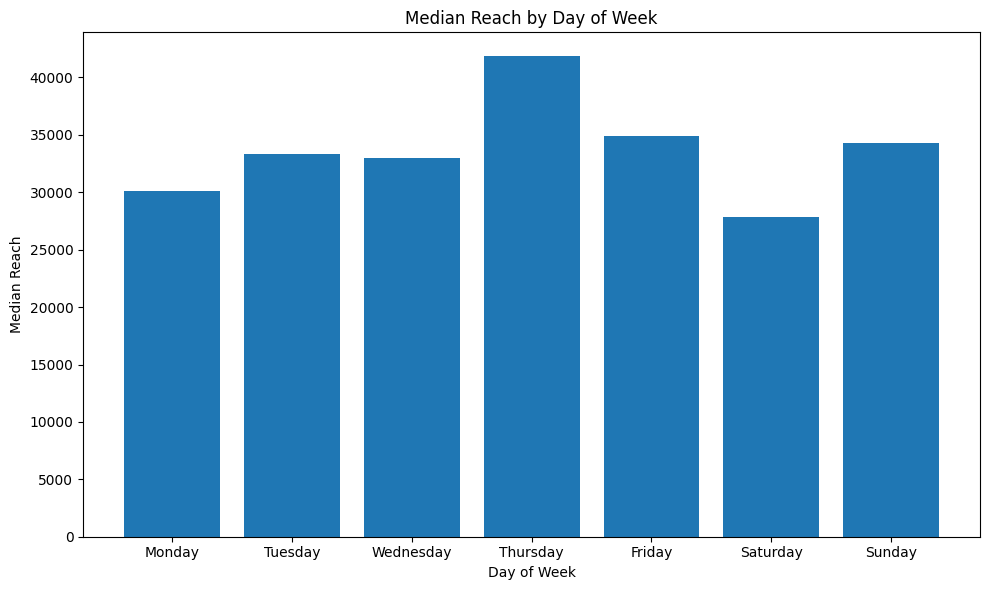

In [ ]:
# Extract day name from posting date
df["Day of Week"] = df["Date"].dt.day_name()

# Define day order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Calculate median reach by day of week
median_reach_per_day = (
    df.groupby("Day of Week")["Reach"]
      .median()
      .reindex(day_order)
)

# Display median reach values
print("Median Reach by Day of Week")
print(median_reach_per_day)

# Create bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    median_reach_per_day.index,
    median_reach_per_day.values
)

plt.title("Median Reach by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Median Reach")

plt.tight_layout()
plt.show()

Median Engagement by Post Hour
Post Hour
0     2178.0
1       61.0
2      119.0
3       24.0
4     4474.5
5     1955.0
6     2265.5
7     3078.0
8      997.0
9     1714.0
10    1405.0
11     667.0
12    1342.0
13    1426.5
14    1572.0
15    1294.0
16    1271.0
17     914.0
18    2171.0
19    1894.0
20    1494.0
21    2657.0
22    1559.5
23    3158.0
Name: Engagement, dtype: float64


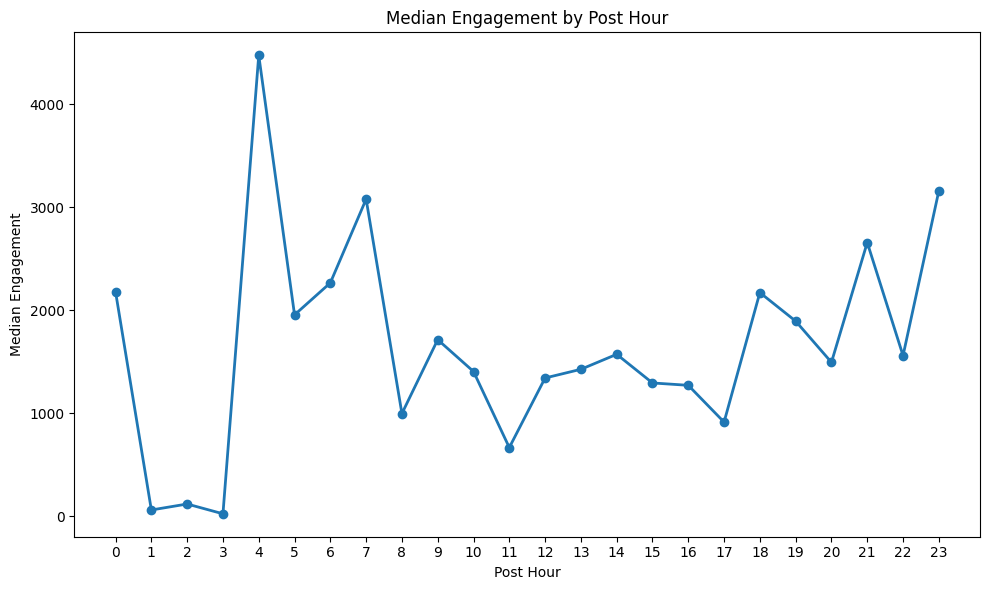

In [ ]:
# Extract posting hour
df["Post Hour"] = df["Date"].dt.hour

# Calculate median engagement by posting hour
median_engagement_per_hour = (
    df.groupby("Post Hour")["Engagement"]
      .median()
      .reindex(range(24))
)

# Display median engagement values
print("Median Engagement by Post Hour")
print(median_engagement_per_hour)

# Create line chart
plt.figure(figsize=(10, 6))

plt.plot(
    median_engagement_per_hour.index,
    median_engagement_per_hour.values,
    marker="o",
    linewidth=2
)

plt.title("Median Engagement by Post Hour")
plt.xlabel("Post Hour")
plt.ylabel("Median Engagement")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

Median Reach by Post Hour
Post Hour
0      55424.0
1       6667.5
2      10954.0
3       1793.0
4     122654.0
5      42590.0
6      34865.5
7      69140.0
8      24510.0
9      38257.0
10     24264.5
11     12317.0
12     27783.0
13     33165.0
14     40294.5
15     23097.0
16     29497.0
17     30982.5
18     50385.5
19     39859.0
20     41465.5
21     49165.0
22     38528.0
23     52272.0
Name: Reach, dtype: float64


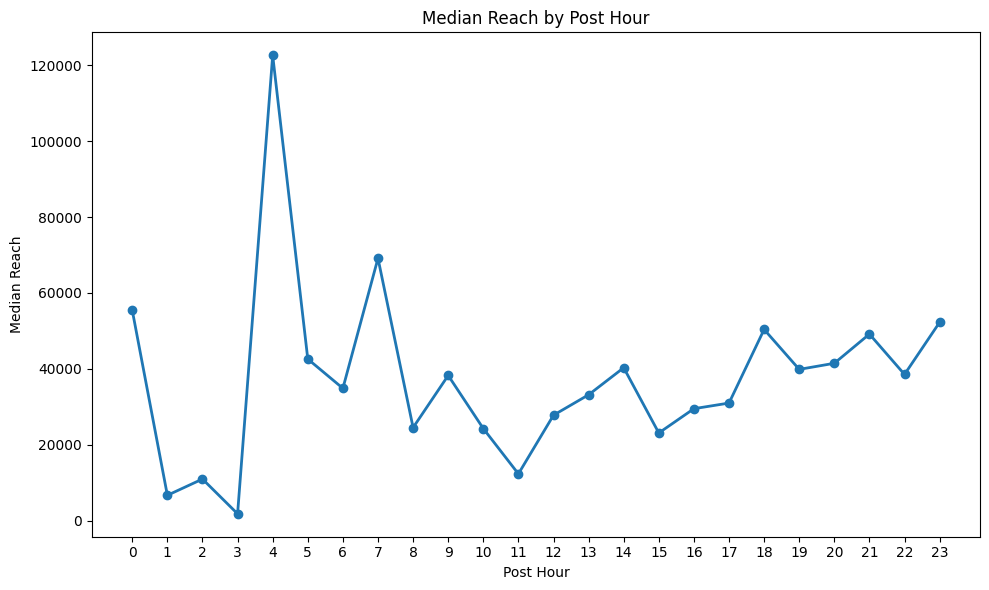

In [ ]:
# Extract posting hour
df["Post Hour"] = df["Date"].dt.hour

# Calculate median reach by posting hour
median_reach_per_hour = (
    df.groupby("Post Hour")["Reach"]
      .median()
      .reindex(range(24))
)

# Display median reach values
print("Median Reach by Post Hour")
print(median_reach_per_hour)

# Create line chart
plt.figure(figsize=(10, 6))

plt.plot(
    median_reach_per_hour.index,
    median_reach_per_hour.values,
    marker="o",
    linewidth=2
)

plt.title("Median Reach by Post Hour")
plt.xlabel("Post Hour")
plt.ylabel("Median Reach")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

# Reach Prediction

In [ ]:
# Feature engineering

# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Text
# df["caption_length"] = df["Text"].astype(str).str.len()
df["word_count"] = df["Text"].astype(str).str.split().str.len()
df["hashtag_count"] = df["Text"].astype(str).str.count(r"#\w+")

# Date
df["posting_hour"] = df["Date"].dt.hour
df["posting_day"] = df["Date"].dt.day_name()
# df["posting_month"] = df["Date"].dt.month

In [ ]:
# Encoding
account_encoder = LabelEncoder()
type_encoder = LabelEncoder()
day_encoder = LabelEncoder()

df["account_encoded"] = account_encoder.fit_transform(df["Profile"])
df["type_encoded"] = type_encoder.fit_transform(df["Type"])
df["day_encoded"] = day_encoder.fit_transform(df["posting_day"])

In [ ]:
# Features

df["Engagement_log"] = np.log1p(df["Engagement"])

features = [
    "account_encoded",
    "type_encoded",
    "word_count",
    "hashtag_count",
    "posting_hour",
    "day_encoded",
    "Engagement_log",
    "Engagement Rate",
    "Followers"
]

X = df[features]
y = np.log1p(df["Reach"])

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Display the shapes of the splits for verification
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")
print(f"Training Target Shape: {y_train.shape}")
print(f"Testing Target Shape: {y_test.shape}")

Training Features Shape: (2998, 9)
Testing Features Shape: (750, 9)
Training Target Shape: (2998,)
Testing Target Shape: (750,)


In [ ]:
# Model Initialization

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=5, random_state=42)
}

# Display model names to confirm initialization
print("Models initialized:", list(models.keys()))

Models initialized: ['Linear Regression', 'Random Forest', 'XGBoost']


In [ ]:
# Evaluation Function
def evaluate_model(model_name, y_true, y_pred):

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n{model_name}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")

    return {
        "Model": model_name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }


Training and evaluating: Linear Regression

Linear Regression
R²   : 0.9218
MAE  : 0.4453
RMSE : 0.5794


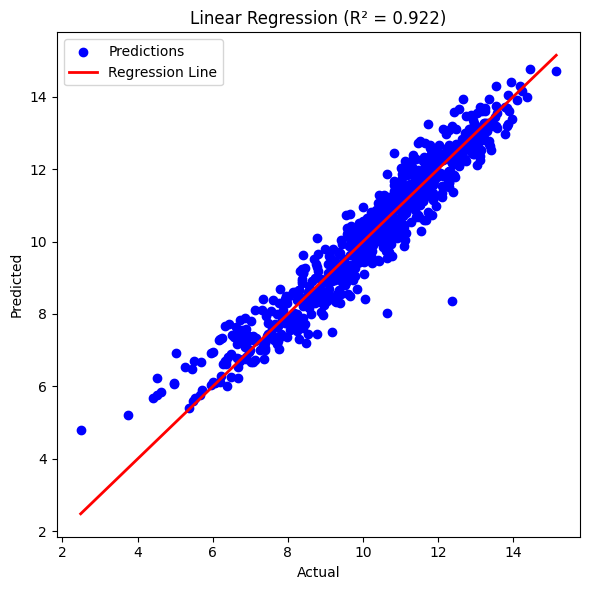


Training and evaluating: Random Forest

Random Forest
R²   : 0.9538
MAE  : 0.3055
RMSE : 0.4454


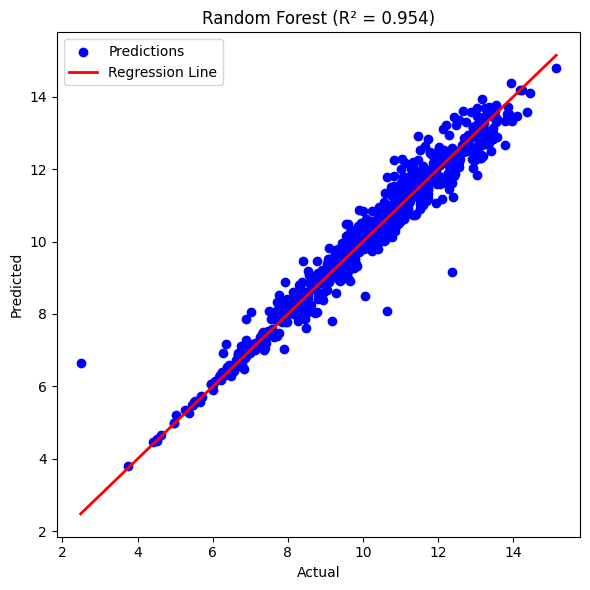


Training and evaluating: XGBoost

XGBoost
R²   : 0.9568
MAE  : 0.2945
RMSE : 0.4309


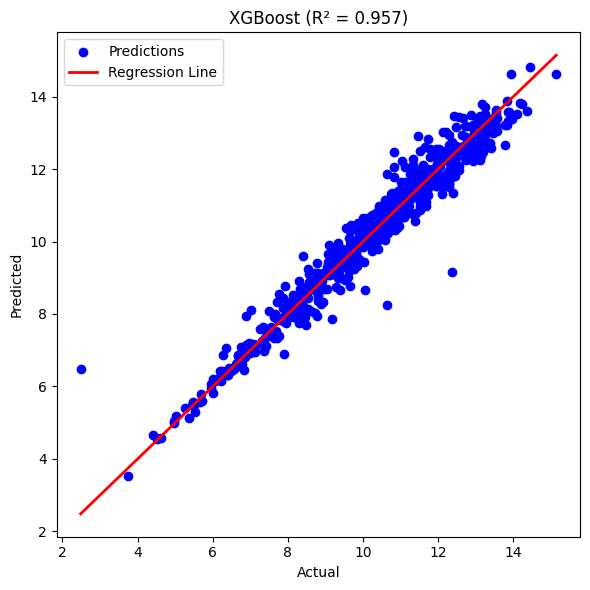

In [ ]:
# Train & Evaluation
results = []

for model_name, model in models.items():

    print(f"\nTraining and evaluating: {model_name}")

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Evaluation
    result = evaluate_model(
        model_name,
        y_test,
        y_pred
    )

    results.append(result)

    # Calculate R² for plot title
    r2 = r2_score(y_test, y_pred)

    # Actual vs Predicted Plot
    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_test,
        y_pred,
        color="blue",
        label="Predictions"
    )

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="red",
        linewidth=2,
        label="Regression Line"
    )

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{model_name} (R² = {r2:.3f})")
    plt.legend()

    plt.tight_layout()
    plt.show()


MODEL COMPARISON
               Model        R2       MAE      RMSE
0            XGBoost  0.956783  0.294515  0.430863
1      Random Forest  0.953824  0.305484  0.445369
2  Linear Regression  0.921846  0.445307  0.579415

BEST MODEL
     Model        R2       MAE      RMSE
0  XGBoost  0.956783  0.294515  0.430863

FEATURE IMPORTANCE
           Feature  Importance
7  Engagement Rate    0.389616
6   Engagement_log    0.378085
1     type_encoded    0.193715
0  account_encoded    0.022127
4     posting_hour    0.003842
2       word_count    0.003619
3    hashtag_count    0.003386
8        Followers    0.003145
5      day_encoded    0.002465


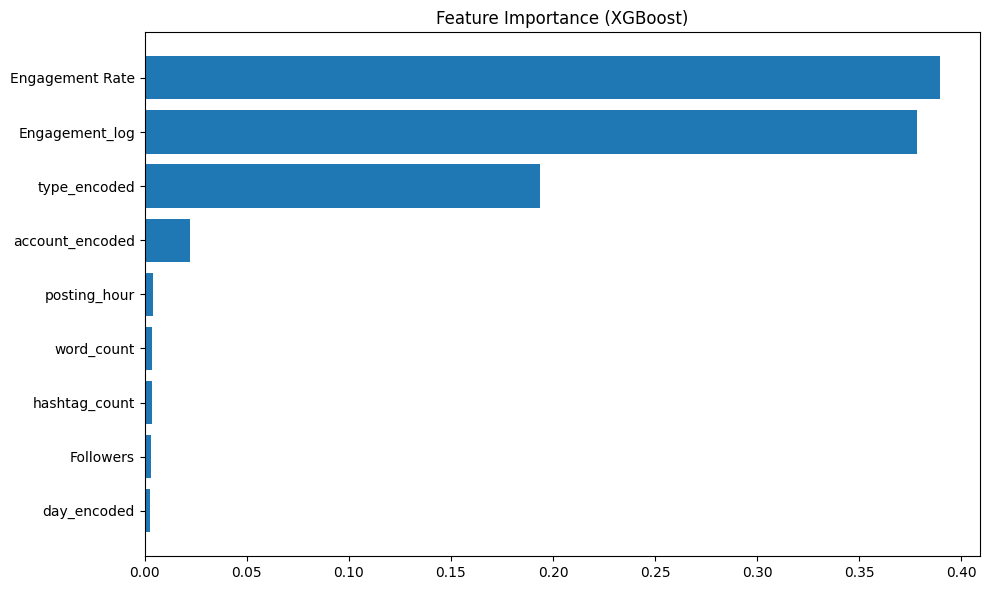

In [ ]:
# Model Comparison
results_df = pd.DataFrame(results).sort_values(
    by="R2",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

print("\nMODEL COMPARISON")
print(results_df)

print("\nBEST MODEL")
print(results_df.head(1))

# Best Model
best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

# Feature Importance
if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    }).sort_values(
        by="Importance",
        ascending=False
    )

    print("\nFEATURE IMPORTANCE")
    print(importance)

    plt.figure(figsize=(10,6))
    plt.barh(importance["Feature"], importance["Importance"])
    plt.gca().invert_yaxis()
    plt.title(f"Feature Importance ({best_model_name})")
    plt.tight_layout()
    plt.show()

else:

    print(f"{best_model_name} does not support feature importance.")

In [ ]:
# Number of posts using hashtags
posts_with_hashtags_count = (df["hashtag_count"] > 0).sum()

# Number of posts without hashtags
posts_without_hashtags_count = (df["hashtag_count"] == 0).sum()

print(f"Number of posts with hashtags: {posts_with_hashtags_count}")
print(f"Number of posts without hashtags: {posts_without_hashtags_count}")

# Median Reach for posts with hashtags
median_reach_with_hashtags = df[df["hashtag_count"] > 0]["Reach"].median()

# Median Reach for posts without hashtags
median_reach_without_hashtags = df[df["hashtag_count"] == 0]["Reach"].median()

print(f"\nMedian Reach for posts with hashtags: {median_reach_with_hashtags}")
print(f"Median Reach for posts without hashtags: {median_reach_without_hashtags}")

Number of posts with hashtags: 3367
Number of posts without hashtags: 381

Median Reach for posts with hashtags: 41888.0
Median Reach for posts without hashtags: 2852.0


In [ ]:
df.to_csv("instagram_data_final.csv", index=False)